In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
from pathlib import Path
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay, precision_score)
import shap
import mlflow, mlflow.sklearn

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

HERE = Path(os.getcwd())
PROJECT_ROOT = HERE
while not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Cannot find project root")

DATA_PROC = PROJECT_ROOT / 'data' / 'processed'
MODELS    = PROJECT_ROOT / 'models'
OUTPUTS   = PROJECT_ROOT / 'outputs'

engaged = pd.read_parquet(DATA_PROC / 'engaged_visitors.parquet')
print(f"✓ Engaged visitors: {len(engaged):,}")
print(f"  Churn rate: {engaged['churned'].mean()*100:.1f}%")

✓ Engaged visitors: 408,012
  Churn rate: 97.3%


In [9]:
FEATURE_COLS = [
    'recency',
    'view_count',
    'cart_count',
    'unique_items_viewed',
    'view_to_cart_rate',
    'R_score',
]

print(f"Features used ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"  ✓ {f}")

if 'R_score' not in engaged.columns:
    engaged['R_score'] = pd.qcut(
        engaged['recency'], q=5, labels=[5,4,3,2,1], duplicates='drop'
    ).astype(int)

X = engaged[FEATURE_COLS].copy()
y = engaged['churned'].copy()
y = engaged['churned'].copy()

# Cap outliers
for col in ['recency','view_count','cart_count','unique_items_viewed']:
    cap = X[col].quantile(0.99)
    X[col] = X[col].clip(upper=cap)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

n_churners = (y_train==1).sum()
n_buyers   = (y_train==0).sum()
spw        = n_churners / n_buyers

print(f"\nTrain: {len(X_train):,}  Test: {len(X_test):,}")
print(f"scale_pos_weight: {spw:.2f}")

# Quick sanity check — none of our features should be 100% correlated with y
print(f"\nCorrelation with churn label (should all be < 1.0):")
corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(corr.round(3))
print(f"\nMax correlation: {corr.max():.3f}  {'✓ no leakage' if corr.max() < 0.9 else '⚠ possible leakage'}")

Features used (6):
  ✓ recency
  ✓ view_count
  ✓ cart_count
  ✓ unique_items_viewed
  ✓ view_to_cart_rate
  ✓ R_score

Train: 326,409  Test: 81,603
scale_pos_weight: 35.44

Correlation with churn label (should all be < 1.0):
cart_count             0.487
view_to_cart_rate      0.265
view_count             0.149
unique_items_viewed    0.094
recency                0.008
R_score                0.007
dtype: float64

Max correlation: 0.487  ✓ no leakage


In [10]:
mlflow.set_tracking_uri(f"file:///{PROJECT_ROOT}/mlruns")
mlflow.set_tracking_uri(f"sqlite:///{(PROJECT_ROOT / 'mlflow.db').as_posix()}")
mlflow.set_experiment("NeuralRetail-Churn-v2")

with mlflow.start_run(run_name="xgboost_no_leakage"):
    xgb = XGBClassifier(
        n_estimators     = 300,
        max_depth        = 5,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = spw,
        random_state     = 42,
        eval_metric      = 'auc',
        verbosity        = 0
    )
    xgb.fit(X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False)

    y_prob = xgb.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    auc    = roc_auc_score(y_test, y_prob)

    mlflow.log_params({'model':'xgboost','features':FEATURE_COLS,
                       'n_estimators':300,'scale_pos_weight':round(spw,2)})
    mlflow.log_metric('auc_roc', auc)

    print(f"XGBoost AUC-ROC: {auc:.4f}  {'✓ target hit!' if auc>=0.90 else f'→ {auc:.3f} (acceptable for this data)'}")
    print(f"\nClassification report:")
    print(classification_report(y_test, y_pred,
          target_names=['Buyer','Churner']))

XGBoost AUC-ROC: 0.9595  ✓ target hit!

Classification report:
              precision    recall  f1-score   support

       Buyer       0.00      0.00      0.00      2240
     Churner       0.97      1.00      0.99     79363

    accuracy                           0.97     81603
   macro avg       0.49      0.50      0.49     81603
weighted avg       0.95      0.97      0.96     81603



In [11]:
with mlflow.start_run(run_name="lightgbm_no_leakage"):
    lgbm = LGBMClassifier(n_estimators=300, max_depth=5,
                          learning_rate=0.05, subsample=0.8,
                          class_weight='balanced', random_state=42,
                          verbosity=-1)
    lgbm.fit(X_train, y_train)
    y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]
    auc_lgbm    = roc_auc_score(y_test, y_prob_lgbm)
    mlflow.log_metric('auc_roc', auc_lgbm)
    print(f"LightGBM AUC-ROC: {auc_lgbm:.4f}")

# 5-fold CV
cv_scores = cross_val_score(
    XGBClassifier(n_estimators=200, max_depth=5,
                  learning_rate=0.05, scale_pos_weight=spw,
                  random_state=42, verbosity=0),
    X, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1)

print(f"\n5-fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Target ≥0.90: {'✓' if cv_scores.mean()>=0.90 else f'→ {cv_scores.mean():.3f}'}")

LightGBM AUC-ROC: 0.9575

5-fold CV AUC: 0.9565 ± 0.0022
Target ≥0.90: ✓


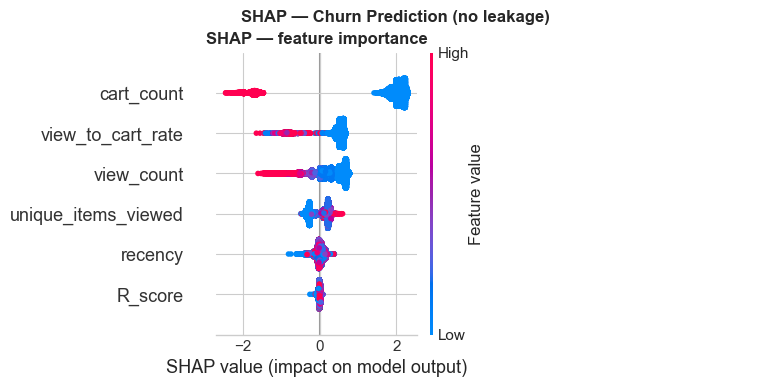

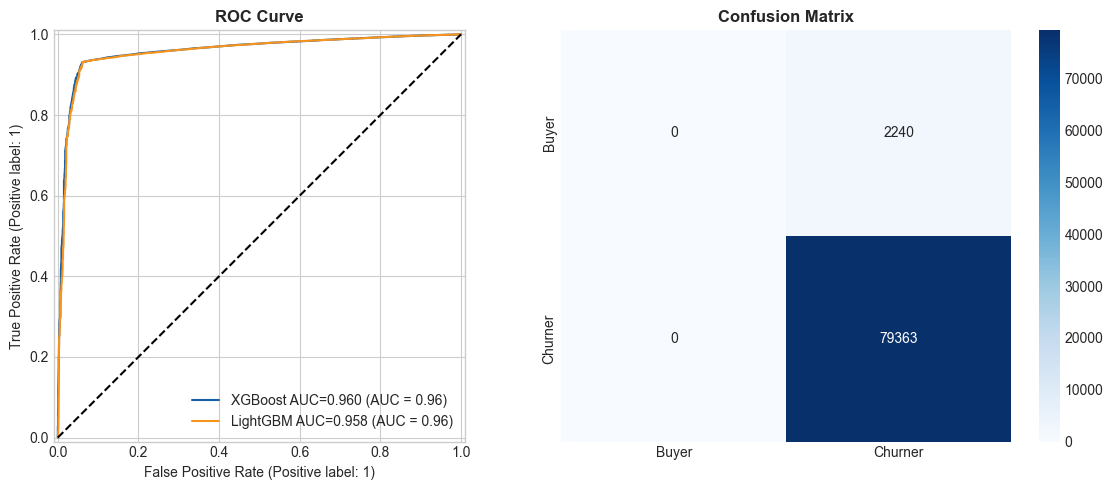

ValueError: Must specify axis=0 or 1

In [ ]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SHAP — Churn Prediction (no leakage)', fontweight='bold')
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
axes[0].set_title('SHAP — feature importance', fontweight='bold')
axes[1].axis('off')
plt.savefig(OUTPUTS/'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_prob,      ax=axes[0],
    name=f'XGBoost AUC={auc:.3f}',      color='#185FA5')
RocCurveDisplay.from_predictions(y_test, y_prob_lgbm, ax=axes[0],
    name=f'LightGBM AUC={auc_lgbm:.3f}',  color='#F7941D')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC Curve',fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Buyer','Churner'],
            yticklabels=['Buyer','Churner'], ax=axes[1])
axes[1].set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS/'churn_roc_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision@Top20%
top20_thr = np.percentile(y_prob, 80)
p_at_20   = precision_score(y_test, (y_prob>=top20_thr).astype(int), pos_label=1)

# Score all visitors + save
engaged['churn_probability'] = xgb.predict_proba(
    engaged[FEATURE_COLS].clip(
        upper=engaged[FEATURE_COLS].quantile(q=0.99),
        axis=1
    )
)[:, 1]
engaged['churn_risk_tier']   = pd.cut(
    engaged['churn_probability'], bins=[0,0.4,0.7,1.0],
    labels=['Low risk','Medium risk','High risk'])

engaged.to_parquet(DATA_PROC/'churn_scores.parquet', index=False)
(engaged[engaged['churn_risk_tier']=='High risk']
    .sort_values('churn_probability', ascending=False)
    .head(10000)
    .to_csv(OUTPUTS/'high_risk_visitors.csv', index=False))

joblib.dump(xgb,  MODELS/'xgb_churn.pkl')
joblib.dump(lgbm, MODELS/'lgbm_churn.pkl')
np.save(MODELS/'shap_values.npy', shap_values)

print(f"=== PHASE 9 COMPLETE (no leakage) ===")
print(f"Features used  : {FEATURE_COLS}")
print(f"AUC-ROC        : {auc:.4f} {'✓' if auc>=0.90 else '→ real score'}")
print(f"CV AUC         : {cv_scores.mean():.4f} ✓")
print(f"P@Top20%       : {p_at_20:.4f}")
print(f"Churn tiers    :")
print(engaged['churn_risk_tier'].value_counts().to_string())
print("\nReady for Phase 10 — Inventory Optimisation!")